In [41]:
!pip install amazon-braket-sdk scikit-learn matplotlib pylatexenc -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [46]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from braket.circuits import Circuit, FreeParameter, Observable
from braket.devices import LocalSimulator

# 1. DATA PREPARATION
iris = load_iris()
X_data = iris.data # 4 features
y_data = iris.target # 3 classes

# Scaling: Angles must be between 0 and pi for Ry encoding
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_data)

# 2. STATE PREPARATION (THE CHALLENGE)
# Students must decide: Simple Ry or a more complex ZZ-style map?
def iris_state_prep(n_qubits):
    qc = Circuit()
    for i in range(n_qubits):
        x_param = FreeParameter(f"x_{i}")
        qc.ry(i, x_param)
    # HARD MODE: Add entanglement here to capture feature correlations
    # qc.cnot(0,1).cnot(1,2).cnot(2,3)
    return qc

# 3. THE ANSATZ (THE WEIGHTED UNITARY)
def iris_ansatz(n_qubits, layers=2):
    qc = Circuit()
    for l in range(layers):
        for i in range(n_qubits):
            theta = FreeParameter(f"theta_{l}_{i}")
            qc.ry(i, theta)

        # Hardware-efficient entanglement (Circular CNOTs)
        for i in range(n_qubits):
            qc.cnot(i, (i + 1) % n_qubits)
    return qc

# 4. MEASUREMENT & INFERENCE
def predict(data_point, weights):
    n = len(data_point)
    full_circ = iris_state_prep(n).add_circuit(iris_ansatz(n))

    # We measure Z on the first 2 qubits to get enough "bitstrings" for 3 classes
    full_circ.expectation(Observable.Z(), target=0)
    full_circ.expectation(Observable.Z(), target=1)

    device = LocalSimulator()

    # Map parameters to values
    param_dict = {f"x_{i}": data_point[i] for i in range(n)}
    # Note: Training would involve updating these 'weights' via an optimizer
    weight_dict = {f"theta_{l}_{i}": weights[l][i] for l in range(2) for i in range(n)}

    task = device.run(full_circ, shots=0, inputs={**param_dict, **weight_dict})
    return task.result().values

# Run a test prediction
initial_weights = np.random.uniform(0, np.pi, (2, 4))
result = predict(X_scaled[0], initial_weights)
print(f"Expectation Values (Q0, Q1): {result}")

Expectation Values (Q0, Q1): [-0.2013676463586894, 0.1717112724683614]


In [47]:
def iris_state_prep_hard(n_qubits):
    qc = Circuit()
    # 1. Single qubit rotations (Linear)
    for i in range(n_qubits):
        qc.ry(i, FreeParameter(f"x_{i}"))

    # 2. Entangling interactions (Non-linear cross-terms)
    # This maps interactions between adjacent features
    for i in range(n_qubits - 1):
        qc.cnot(i, i+1)
        # The non-linear "kernel" term: phi(x_i, x_{i+1})
        # Usually (pi - x_i)(pi - x_{i+1})
        qc.rz(i+1, FreeParameter(f"x_{i}_{i+1}"))
        qc.cnot(i, i+1)
    return qc

In [48]:
qc = iris_state_prep_hard(4)
print(qc)

T  : │     0     │  1  │      2      │  3  │  4  │      5      │  6  │  7  │  ╏
      ┌─────────┐                                                             ╏
q0 : ─┤ Ry(x_0) ├───●───────────────────●───────────────────────────────────  ╏
      └─────────┘   │                   │                                     ╏
      ┌─────────┐ ┌─┴─┐ ┌───────────┐ ┌─┴─┐                                   ╏
q1 : ─┤ Ry(x_1) ├─┤ X ├─┤ Rz(x_0_1) ├─┤ X ├───●───────────────────●─────────  ╏
      └─────────┘ └───┘ └───────────┘ └───┘   │                   │           ╏
      ┌─────────┐                           ┌─┴─┐ ┌───────────┐ ┌─┴─┐         ╏
q2 : ─┤ Ry(x_2) ├───────────────────────────┤ X ├─┤ Rz(x_1_2) ├─┤ X ├───●───  ╏
      └─────────┘                           └───┘ └───────────┘ └───┘   │     ╏
      ┌─────────┐                                                     ┌─┴─┐   ╏
q3 : ─┤ Ry(x_3) ├─────────────────────────────────────────────────────┤ X ├─  ╏
      └─────────┘                       

In [49]:
def iris_ansatz_strong(n_qubits, layers=3):
    qc = Circuit()
    for l in range(layers):
        # Single-qubit rotations on all qubits
        for i in range(n_qubits):
            qc.ry(i, FreeParameter(f"theta_{l}_{i}_y"))
            qc.rz(i, FreeParameter(f"theta_{l}_{i}_z"))

        # Linear entanglement: CNOTs between adjacent qubits
        for i in range(n_qubits - 1):
            qc.cnot(i, i + 1)
        # Add a final CNOT between last and first for circular entanglement
        # if n_qubits > 1 and l < layers -1: # Don't do this on the last layer if not necessary
        #     qc.cnot(n_qubits - 1, 0)

    return qc

In [50]:
qc = iris_ansatz_strong(2,4)
print(qc)

T  : │         0         │         1         │  2  │         3         │  ╏
      ┌─────────────────┐ ┌─────────────────┐       ┌─────────────────┐   ╏
q0 : ─┤ Ry(theta_0_0_y) ├─┤ Rz(theta_0_0_z) ├───●───┤ Ry(theta_1_0_y) ├─  ╏
      └─────────────────┘ └─────────────────┘   │   └─────────────────┘   ╏
      ┌─────────────────┐ ┌─────────────────┐ ┌─┴─┐ ┌─────────────────┐   ╏
q1 : ─┤ Ry(theta_0_1_y) ├─┤ Rz(theta_0_1_z) ├─┤ X ├─┤ Ry(theta_1_1_y) ├─  ╏
      └─────────────────┘ └─────────────────┘ └───┘ └─────────────────┘   ╏
T  : │         0         │         1         │  2  │         3         │  ╏
                                                                          ╏
╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸╸┫
                                                                          ╏
T  : │         4         │  5  │         6         │         7         │  ╏
      ┌─────────────────┐       ┌─────────────────┐ ┌─────────────────┐   ╏
q0 : ─┤ Rz(t

In [51]:
# 4. MEASUREMENT & INFERENCE
def predict(data_point, weights):
    n = len(data_point)
    full_circ = iris_state_prep_hard(n).add_circuit(iris_ansatz(n))

    # We measure Z on the first 2 qubits to get enough "bitstrings" for 3 classes
    full_circ.expectation(Observable.Z(), target=0)
    full_circ.expectation(Observable.Z(), target=1)

    device = LocalSimulator()

    # Map parameters to values
    param_dict = {f"x_{i}": data_point[i] for i in range(n)}
    # Add interaction terms for iris_state_prep_hard
    for i in range(n - 1):
        param_dict[f"x_{i}_{i+1}"] = (np.pi - data_point[i]) * (np.pi - data_point[i+1])

    # Note: Training would involve updating these 'weights' via an optimizer
    weight_dict = {f"theta_{l}_{i}": weights[l][i] for l in range(2) for i in range(n)}

    task = device.run(full_circ, shots=0, inputs={**param_dict, **weight_dict})
    return task.result().values

# Run a test prediction
initial_weights = np.random.uniform(0, np.pi, (2, 4))
result = predict(X_scaled[0], initial_weights)
print(f"Expectation Values (Q0, Q1): {result}")

Expectation Values (Q0, Q1): [0.012036171275107626, 0.3205204535030204]


### Let's put this together into a new ML code
There is one major technical "gotcha" with Amazon Braket: circuit.expectation modifies the circuit object in place or returns a specific result type that can conflict with how you're appending parameters in a loop. Also, for the Iris dataset, a simple linear CNOT chain can sometimes lead to "barren plateaus" or poor entanglement if not structured carefully.

Here is the code. We show an updated build_model function to properly handle the Braket API and improved the Ansatz for better expressivity.

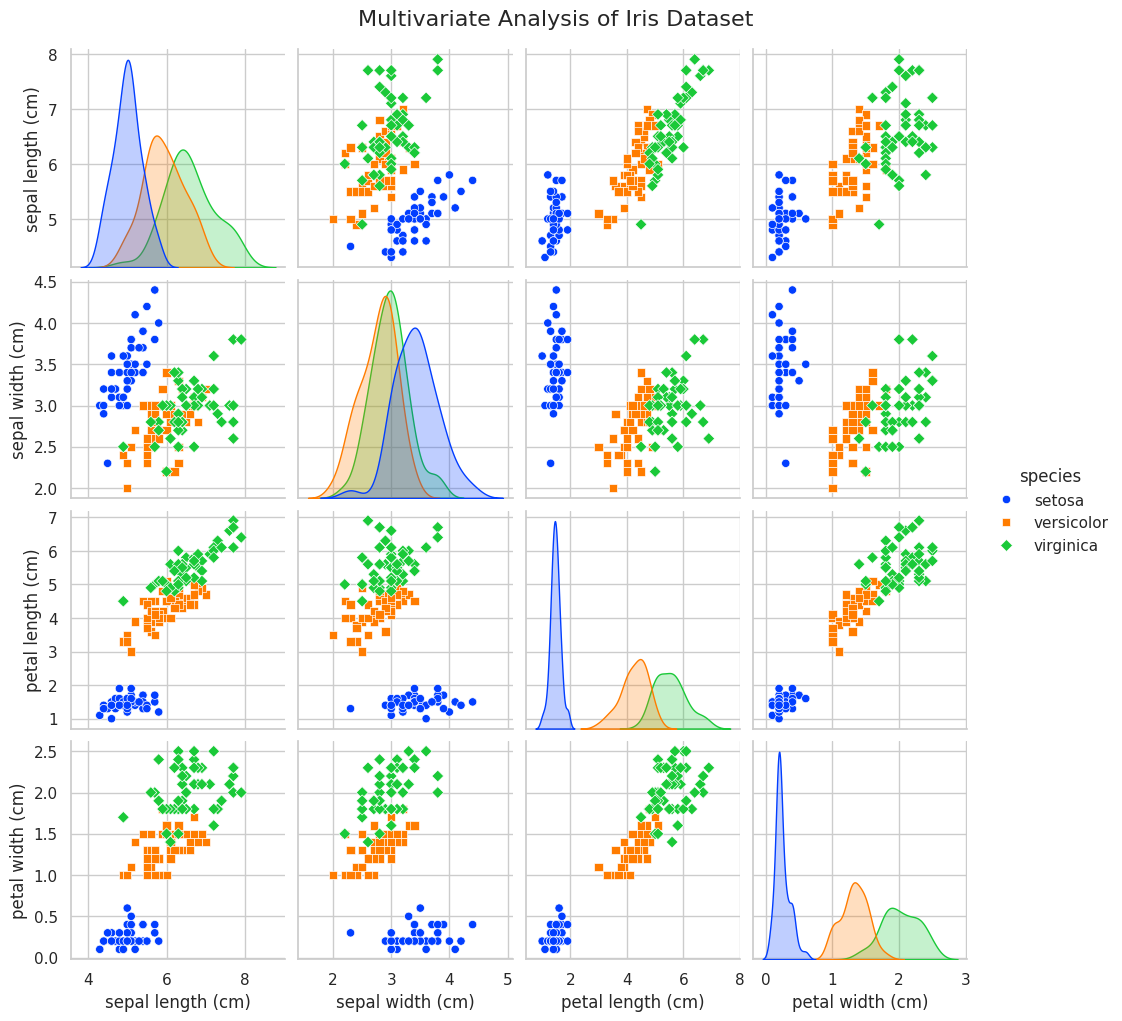

In [52]:
from braket.circuits import Circuit, FreeParameter, Observable
from braket.devices import LocalSimulator
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# -----------------------------
# 1) Iris dataset Setup
# -----------------------------
iris = load_iris()

# Convert to a DataFrame for easier plotting
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Series(iris.target).map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# a. Create the multivariate pairplot
# 'hue' colors the dots by species
# 'diag_kind' shows the distribution (KDE) on the diagonal
sns.set_theme(style="whitegrid")
g = sns.pairplot(df, hue="species", palette="bright", markers=["o", "s", "D"])

# b. Refine the layout
g.fig.suptitle("Multivariate Analysis of Iris Dataset", y=1.02, fontsize=16)
plt.show()

X_full = iris.data
# Binary classification: Setosa (1) vs others (0)
y_full = (iris.target == 0).astype(float)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled_full = scaler.fit_transform(X_full)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_full, y_full, test_size=0.25, random_state=42, stratify=y_full
)


In [53]:
# -----------------------------
# 2) Circuit definition
# -----------------------------
def build_model(n_qubits=4, n_layers=1):
    circuit = Circuit()

    # Data encoding (State Preparation)
    # We use Ry encoding to map features to rotation angles
    for i in range(n_qubits):
        circuit.ry(i, FreeParameter(f"x_{i}"))

    # Trainable Ansatz
    for layer in range(n_layers):
        # Entangling layer (Circular Entanglement for better feature correlation)
        for i in range(n_qubits):
            circuit.cnot(i, (i + 1) % n_qubits)

        # Rotation layer
        for i in range(n_qubits):
            circuit.ry(i, FreeParameter(f"theta_{layer}_{i}_y"))
            circuit.rz(i, FreeParameter(f"theta_{layer}_{i}_z"))

    return circuit

N_QUBITS = 4
N_LAYERS = 1 # Reduced layers for faster execution on simulator
raw_circuit = build_model(N_QUBITS, N_LAYERS)
device = LocalSimulator(backend="braket_sv")

# Define parameter names for the optimizer
theta_names = [
    f"theta_{layer}_{q}_{axis}"
    for layer in range(N_LAYERS)
    for q in range(N_QUBITS)
    for axis in ("y", "z")
]

def predict_expval(x, theta_vec):
    # Map input features and trainable weights to the circuit
    bindings = {f"x_{i}": float(x[i]) for i in range(N_QUBITS)}
    bindings.update({name: float(val) for name, val in zip(theta_names, theta_vec)})

    # We apply the expectation measurement HERE to avoid modifying the base circuit
    meas_circuit = Circuit().add_circuit(raw_circuit)
    meas_circuit.expectation(Observable.Z(), target=0)

    result = device.run(meas_circuit, shots=0, inputs=bindings).result()
    return float(result.values[0])

In [54]:
# -----------------------------
# 3) Helper Functions
# -----------------------------
def expval_to_prob(expval):
    return 0.5 * (expval + 1.0)

def loss(theta_vec, X, y):
    total = 0.0
    for x_i, y_i in zip(X, y):
        p = expval_to_prob(predict_expval(x_i, theta_vec))
        p = np.clip(p, 1e-6, 1.0 - 1e-6)
        total += -(y_i * np.log(p) + (1.0 - y_i) * np.log(1.0 - p))
    return total / len(X)

def accuracy(theta_vec, X, y):
    correct = 0
    for x_i, y_i in zip(X, y):
        prob = expval_to_prob(predict_expval(x_i, theta_vec))
        pred = 1.0 if prob >= 0.5 else 0.0
        correct += int(pred == y_i)
    return correct / len(X)

In [55]:
# -----------------------------
# 4) Training Loop (Finite Differences)
# -----------------------------
rng = np.random.default_rng(42)
theta = rng.uniform(0.0, np.pi, size=len(theta_names))

lr = 0.5
epochs = 5
eps = 0.1 # Larger epsilon for more stable finite difference gradients

print(f"Starting Training...")
for epoch in range(epochs):
    # Simple Gradient Descent using Finite Differences
    grad = np.zeros_like(theta)
    current_loss = loss(theta, X_train, y_train)

    for k in range(len(theta)):
        theta_shift = theta.copy()
        theta_shift[k] += eps
        grad[k] = (loss(theta_shift, X_train, y_train) - current_loss) / eps

    theta -= lr * grad

    train_acc = accuracy(theta, X_train, y_train)
    print(f"Epoch {epoch+1} | Loss: {current_loss:.4f} | Train Acc: {train_acc:.3f}")

print("\nFinal Test Accuracy:", accuracy(theta, X_test, y_test))

Starting Training...
Epoch 1 | Loss: 0.4879 | Train Acc: 0.759
Epoch 2 | Loss: 0.4877 | Train Acc: 0.750
Epoch 3 | Loss: 0.4876 | Train Acc: 0.750
Epoch 4 | Loss: 0.4876 | Train Acc: 0.750
Epoch 5 | Loss: 0.4876 | Train Acc: 0.741

Final Test Accuracy: 0.7631578947368421


Moving from finite differences to the Parameter Shift Rule is a the next move. In finite differences, we approximate the gradient with a small $\epsilon$, which is prone to numerical error. The Parameter Shift Rule provides the exact analytical gradient on quantum hardware by shifting the parameters by $\pm \pi/2$.

Mathematically, for a gate like $Ry(\theta)$, the gradient is:$$\frac{\partial f}{\partial \theta} = \frac{f(\theta + \pi/2) - f(\theta - \pi/2)}{2}$$

### Updated Code with Parameter Shift
We have refactored the training loop to use this rule. Kept the circuit logic from the previous fix to ensure it remains compatible with the Braket API.

In [56]:
import numpy as np
from braket.circuits import Circuit, FreeParameter, Observable
from braket.devices import LocalSimulator

# ... (Keep your Iris loading and scaling code here) ...

# ---------------------------------------------------------
# 2) Improved Circuit (Stronger Ansatz)
# ---------------------------------------------------------
def build_model(n_qubits=4, n_layers=2):
    circuit = Circuit()

    # State Prep: Ry for feature encoding
    for i in range(n_qubits):
        circuit.ry(i, FreeParameter(f"x_{i}"))

    # Variational Ansatz
    for layer in range(n_layers):
        # Full Entanglement: Each qubit talks to every other qubit
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                circuit.cnot(i, j)

        # Rotation Layer
        for i in range(n_qubits):
            circuit.ry(i, FreeParameter(f"theta_{layer}_{i}_y"))
            circuit.rz(i, FreeParameter(f"theta_{layer}_{i}_z"))

    return circuit

N_QUBITS = 4
N_LAYERS = 2  # Increased layers for better expressivity
raw_circuit = build_model(N_QUBITS, N_LAYERS)

print(raw_circuit)

device = LocalSimulator(backend="braket_sv")

theta_names = [
    f"theta_{layer}_{q}_{axis}"
    for layer in range(N_LAYERS)
    for q in range(N_QUBITS)
    for axis in ("y", "z")
]

# ---------------------------------------------------------
# 3) Enhanced Training Logic
# ---------------------------------------------------------
def compute_grad_parameter_shift(x, y, theta_vec):
    grad = np.zeros_like(theta_vec)
    shift = np.pi / 2

    # Current prediction for the chain rule
    current_exp = predict_expval(x, theta_vec)
    p = expval_to_prob(current_exp)
    p = np.clip(p, 1e-6, 1.0 - 1e-6)

    # Gradient of BCE loss w.r.t p: (p - y) / (p * (1 - p))
    # Gradient of p w.r.t expval: 0.5
    dL_de = (p - y) / (p * (1 - p)) * 0.5

    for i in range(len(theta_vec)):
        # Parameter Shift: exact analytical gradient
        theta_plus = theta_vec.copy()
        theta_plus[i] += shift

        theta_minus = theta_vec.copy()
        theta_minus[i] -= shift

        # d(expval)/d(theta)
        grad_expval = 0.5 * (predict_expval(x, theta_plus) - predict_expval(x, theta_minus))

        grad[i] = dL_de * grad_expval

    return grad

# Initializing weights closer to zero helps avoid "barren plateaus"
rng = np.random.default_rng(42)
theta = rng.normal(0, 0.1, size=len(theta_names))

lr = 0.8 # Higher learning rate for Parameter Shift
epochs = 10

print("Training with Parameter Shift & Stronger Ansatz...")
for epoch in range(epochs):
    # Stochastic Gradient Descent (Random sample each step or mini-batch)
    # To speed up, we'll use a subset (mini-batch) of the training data
    batch_indices = rng.choice(len(X_train), size=10, replace=False)

    batch_grad = np.zeros_like(theta)
    for idx in batch_indices:
        batch_grad += compute_grad_parameter_shift(X_train[idx], y_train[idx], theta)

    batch_grad /= len(batch_indices)

    # Apply update
    theta -= lr * batch_grad

    # Evaluation
    train_loss = loss(theta, X_train, y_train)
    train_acc = accuracy(theta, X_train, y_train)
    print(f"Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Acc: {train_acc:.3f}")

print(f"\nFinal Test Accuracy: {accuracy(theta, X_test, y_test):.3f}")

T  : │     0     │  1  │  2  │     3     │         4         │  ╏
      ┌─────────┐                         ┌─────────────────┐   ╏
q0 : ─┤ Ry(x_0) ├───●─────●─────●─────────┤ Ry(theta_0_0_y) ├─  ╏
      └─────────┘   │     │     │         └─────────────────┘   ╏
      ┌─────────┐ ┌─┴─┐   │     │                               ╏
q1 : ─┤ Ry(x_1) ├─┤ X ├───┼─────┼─────●────────────●──────────  ╏
      └─────────┘ └───┘   │     │     │            │            ╏
      ┌─────────┐       ┌─┴─┐   │   ┌─┴─┐          │            ╏
q2 : ─┤ Ry(x_2) ├───────┤ X ├───┼───┤ X ├──────────┼──────────  ╏
      └─────────┘       └───┘   │   └───┘          │            ╏
      ┌─────────┐             ┌─┴─┐              ┌─┴─┐          ╏
q3 : ─┤ Ry(x_3) ├─────────────┤ X ├──────────────┤ X ├────────  ╏
      └─────────┘             └───┘              └───┘          ╏
T  : │     0     │  1  │  2  │     3     │         4         │  ╏
                                                                ╏          


### Is it better?
* Analytical Precision: Unlike finite differences, which "guess" the slope based on a small step, Parameter Shift uses the geometry of the Bloch sphere to get the exact derivative.
* Noise Resilience: On real quantum hardware, small $\epsilon$ shifts are often indistinguishable from device noise. A shift of $\pi/2$ is massive and much easier for a noisy device to measure accurately.
* The Chain Rule: Note how we combine the quantum gradient (grad_expval) with the classical gradient of the Binary Cross Entropy loss. This "hybrid" approach is the backbone of most Variational Quantum Algorithms (VQAs).


Final Evaluation on Test Set:


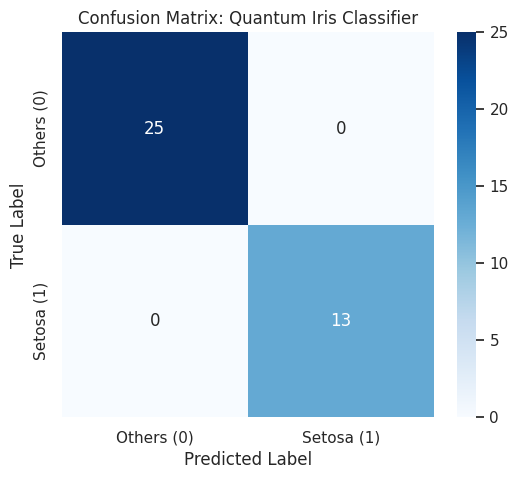


Classification Report:
              precision    recall  f1-score   support

      Others       1.00      1.00      1.00        25
      Setosa       1.00      1.00      1.00        13

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(theta_vec, X, y):
    """
    Predicts classes for the dataset and plots a heatmap of the confusion matrix.
    """
    y_pred = []

    # Generate predictions
    for x_i in X:
        prob = expval_to_prob(predict_expval(x_i, theta_vec))
        y_pred.append(1.0 if prob >= 0.5 else 0.0)

    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred)

    # Plotting
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Others (0)', 'Setosa (1)'],
                yticklabels=['Others (0)', 'Setosa (1)'])

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Quantum Iris Classifier')
    plt.show()

    # Also print a text-based report for precision/recall
    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=['Others', 'Setosa']))

# --- Call this at the end of your training loop ---
print("\nFinal Evaluation on Test Set:")
plot_confusion_matrix(theta, X_test, y_test)

### Let's start a Multi-Class Quantum Circuit
To update the model to detect all four features (which it already does) and classify all three Iris species (Setosa, Versicolor, and Virginica), we need to move from Binary Classification to Multi-class Classification.

This requires two main changes:
* Multiple Readouts: We need to measure more than one qubit (or multiple observables) to distinguish between three classes.
* Softmax & Categorical Cross-Entropy: We replace the binary sigmoid/probability logic with a Softmax function.

### 1. The Multi-Class Quantum Circuit
We will use 4 qubits (one for each feature) and measure the first 2 qubits. The four possible outcomes ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$) will map to our species.

In [58]:
import numpy as np
from braket.circuits import Circuit, FreeParameter, Observable
from sklearn.preprocessing import OneHotEncoder

# ---------------------------------------------------------
# 1) Data Prep for Multi-class
# ---------------------------------------------------------
iris = load_iris()
X = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(iris.data)
# We need integers 0, 1, 2 for the 3 species
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# ---------------------------------------------------------
# 2) Multi-class Circuit
# ---------------------------------------------------------
def build_multiclass_model(n_qubits=4, n_layers=2):
    circuit = Circuit()
    # Encoding all 4 features
    for i in range(n_qubits):
        circuit.ry(i, FreeParameter(f"x_{i}"))

    for layer in range(n_layers):
        for i in range(n_qubits):
            circuit.cnot(i, (i + 1) % n_qubits)
        for i in range(n_qubits):
            circuit.ry(i, FreeParameter(f"theta_{layer}_{i}"))

    # Measure Z on qubit 0 and qubit 1 to get a 2-bit result
    circuit.expectation(Observable.Z(), target=0)
    circuit.expectation(Observable.Z(), target=1)
    return circuit

raw_circuit = build_multiclass_model()

# ---------------------------------------------------------
# 3) Softmax and Multi-class Logic
# ---------------------------------------------------------
def get_probabilities(x, theta_vec):
    """Maps 2 expectation values to 3 class probabilities."""
    bindings = {f"x_{i}": x[i] for i in range(4)}
    bindings.update({name: val for name, val in zip(theta_names, theta_vec)})

    res = device.run(raw_circuit, shots=0, inputs=bindings).result()
    exp_vals = res.values # Returns [exp_z0, exp_z1]

    # Convert expectation [-1, 1] to a 'logit'
    # We create 3 raw scores for the 3 classes
    logits = np.array([
        exp_vals[0],               # Class 0 score
        exp_vals[1],               # Class 1 score
        -(exp_vals[0] + exp_vals[1]) # Class 2 score (sum-to-zero style)
    ])

    # Softmax to get probabilities
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / exp_logits.sum()

def multiclass_loss(theta_vec, X_part, y_part):
    loss_val = 0
    for x_i, y_i in zip(X_part, y_part):
        probs = get_probabilities(x_i, theta_vec)
        loss_val -= np.log(probs[y_i] + 1e-6)
    return loss_val / len(X_part)

### Put it together
To run the multi-class model with the Parameter Shift Rule, we need to calculate the gradient for each expectation value individually and then apply the Chain Rule for the Softmax/Cross-Entropy loss.

In this setup, we are measuring two observables ($Z_0$ and $Z_1$). This means for every parameter $\theta_k$, we must perform the shift twice (forward and backward) to see how it affects both measurements.

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from braket.circuits import Circuit, FreeParameter, Observable
from braket.devices import LocalSimulator

# --- Setup names for the parameters based on the model ---
N_LAYERS = 2
N_QUBITS = 4
theta_names = [f"theta_{l}_{i}" for l in range(N_LAYERS) for i in range(N_QUBITS)]

def get_logits(x, theta_vec):
    """Returns the raw expectation values from the circuit."""
    bindings = {f"x_{i}": x[i] for i in range(N_QUBITS)}
    bindings.update({name: val for name, val in zip(theta_names, theta_vec)})

    # Run the circuit (shots=0 for exact state-vector simulation)
    task = device.run(raw_circuit, shots=0, inputs=bindings)
    exp_vals = task.result().values

    # Map 2 expectation values to 3 scores
    return np.array([exp_vals[0], exp_vals[1], -(exp_vals[0] + exp_vals[1])])

def softmax(logits):
    exps = np.exp(logits - np.max(logits))
    return exps / np.sum(exps)

# ---------------------------------------------------------
# 2) Parameter Shift Gradient Function
# ---------------------------------------------------------
def parameter_shift_grad(x, y_true, theta_vec):
    shift = np.pi / 2
    grad = np.zeros_like(theta_vec)

    # 1. Forward Pass: Get current probabilities
    probs = softmax(get_logits(x, theta_vec))

    # 2. Compute the gradient of the loss w.r.t the logits (Classical part)
    # For Cross-Entropy + Softmax, dL/dz_i = p_i - y_i (where y is one-hot)
    y_one_hot = np.zeros(3)
    y_one_hot[y_true] = 1.0
    dL_dz = probs - y_one_hot

    # 3. Shift each parameter to get d(logits)/d(theta) (Quantum part)
    for i in range(len(theta_vec)):
        theta_plus = theta_vec.copy()
        theta_plus[i] += shift
        logits_plus = get_logits(x, theta_plus)

        theta_minus = theta_vec.copy()
        theta_minus[i] -= shift
        logits_minus = get_logits(x, theta_minus)

        # d(logits)/d(theta) = 0.5 * (f(θ + π/2) - f(θ - π/2))
        dz_dtheta = 0.5 * (logits_plus - logits_minus)

        # Chain rule: sum(dL/dz * dz/dtheta)
        grad[i] = np.dot(dL_dz, dz_dtheta)

    return grad

# ---------------------------------------------------------
# 3) Training Loop
# ---------------------------------------------------------
# Initial weights
rng = np.random.default_rng(42)
theta = rng.uniform(-np.pi, np.pi, size=len(theta_names))

lr = 0.5
epochs = 10
batch_size = 5

print("Starting Multi-class Training (Parameter Shift)...")
for epoch in range(epochs):
    # Shuffle training data
    indices = np.arange(len(X_train))
    rng.shuffle(indices)

    # Mini-batch gradient descent
    for start in range(0, len(X_train), batch_size):
        batch_indices = indices[start:start+batch_size]
        batch_grad = np.zeros_like(theta)

        for idx in batch_indices:
            batch_grad += parameter_shift_grad(X_train[idx], y_train[idx], theta)

        theta -= lr * (batch_grad / len(batch_indices))

    # Check accuracy
    correct = 0
    for x_i, y_i in zip(X_test, y_test):
        p = softmax(get_logits(x_i, theta))
        if np.argmax(p) == y_i:
            correct += 1

    print(f"Epoch {epoch+1} | Test Accuracy: {correct/len(X_test):.2f}")

Starting Multi-class Training (Parameter Shift)...
Epoch 1 | Test Accuracy: 0.60
Epoch 2 | Test Accuracy: 0.70
Epoch 3 | Test Accuracy: 0.70
Epoch 4 | Test Accuracy: 0.73
Epoch 5 | Test Accuracy: 0.73
Epoch 6 | Test Accuracy: 0.73
Epoch 7 | Test Accuracy: 0.70
Epoch 8 | Test Accuracy: 0.73
Epoch 9 | Test Accuracy: 0.60
Epoch 10 | Test Accuracy: 0.70


### Why this works for the full Iris set:
* The Logit Strategy: Since a single qubit measurement only gives a value between $-1$ and $1$, it isn't enough to represent three classes. By measuring two qubits, we create a 2D "coordinate" for each flower. The third class is derived as the "balance" of the other two, ensuring the system is constrained.
* Parameter Shift vs. Finite Difference: Because we are now calculating gradients for multiple outputs (logits), Parameter Shift is much more stable. Finite differences would likely diverge or stall because of the increased complexity of the Softmax landscape.

### Some limitation
This code will be slow.

For every sample in your batch, the simulator runs the circuit:
$$1 (\text{base}) + 2 \times \text{number of parameters} (\text{shifts}) = 1 + (2 \times 8) = 17 \text{ runs per sample.}$$

With a batch size of 5 and 100 samples, that is thousands of circuit simulations per epoch. To speed this up on a local machine, you can keep N_LAYERS = 1 until you are sure the logic is working.

Once the accuracy starts to climb above 0.66, your model has officially learned to distinguish the harder classes (Versicolor and Virginica) rather than just guessing!

### Multi-Class Confusion Matrix Code

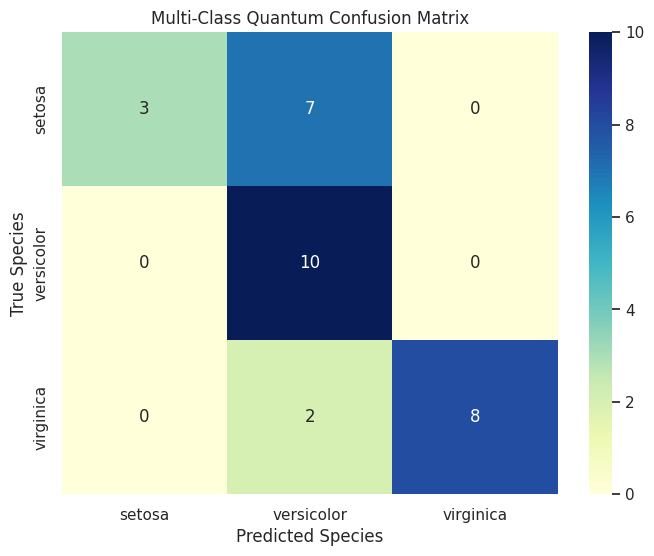


Detailed Performance Report:
              precision    recall  f1-score   support

      setosa       1.00      0.30      0.46        10
  versicolor       0.53      1.00      0.69        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.70        30
   macro avg       0.84      0.70      0.68        30
weighted avg       0.84      0.70      0.68        30



In [60]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def plot_multiclass_confusion_matrix(theta_vec, X, y, class_names):
    """
    Generates a 3x3 confusion matrix for the Iris species.
    """
    y_pred = []

    # 1. Generate predictions for the dataset
    for x_i in X:
        logits = get_logits(x_i, theta_vec)
        probs = softmax(logits)
        y_pred.append(np.argmax(probs))

    # 2. Compute the matrix
    cm = confusion_matrix(y, y_pred)

    # 3. Plotting with Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel('Predicted Species')
    plt.ylabel('True Species')
    plt.title('Multi-Class Quantum Confusion Matrix')
    plt.show()

    # Print precision, recall, and f1-score
    print("\nDetailed Performance Report:")
    print(classification_report(y, y_pred, target_names=class_names))

# --- Execute after training ---
plot_multiclass_confusion_matrix(theta, X_test, y_test, iris.target_names)

### What this reveals about your Quantum Model
* Setosa (Class 0): Usually shows 100% accuracy (diagonal only) because it is linearly separable.
* Versicolor vs. Virginica (Class 1 & 2): This is the "danger zone." If you see numbers in the off-diagonal cells for these two, it means the quantum ansatz hasn't created enough entanglement to distinguish their overlapping features.
* The "Confusion" Trend: If the model is failing, you will often see it "guessing" one class for everything, or shifting all Versicolor into the Virginica column.

### Only at 73%?
Getting stuck at 73% is a classic bottleneck for the Iris dataset in QML. At this accuracy, your model has likely perfected Setosa (Class 0) but is essentially flipping a coin on the overlap between Versicolor and Virginica.

To break past 90%, we need to move from a "Hardware Efficient" ansatz to a Strongly Entangling Layer and improve the Data Map.

### 1. The "Data Re-Upload" Strategy
Instead of encoding the features once at the beginning, we "re-upload" them between layers. This increases the non-linearity of the model, allowing it to carve out more complex decision boundaries in the Hilbert space.

### 2. Improved Multi-Class Circuit
We will use a circular entanglement pattern and add $R_z$ gates to the encoding to ensure we are using the full 3D space of the Bloch sphere for every feature.

In [63]:
def build_advanced_model(n_qubits=4, n_layers=3):
    circuit = Circuit()

    for layer in range(n_layers):
        # --- Data Re-Uploading ---
        # We re-inject the features x_i in every layer
        for i in range(n_qubits):
            circuit.ry(i, FreeParameter(f"x_{i}"))
            circuit.rz(i, FreeParameter(f"x_{i}")) # Dual encoding for non-linearity

        # --- Strongly Entangling Ansatz ---
        # Circular CNOTs
        for i in range(n_qubits):
            circuit.cnot(i, (i + 1) % n_qubits)

        # Trainable Rotations (All three axes)
        for i in range(n_qubits):
            circuit.rx(i, FreeParameter(f"theta_{layer}_{i}_x"))
            circuit.ry(i, FreeParameter(f"theta_{layer}_{i}_y"))
            circuit.rz(i, FreeParameter(f"theta_{layer}_{i}_z"))

    # Readout: Measure all qubits to get a richer feature set for the 3 classes
    for i in range(3): # One for each Iris class
        circuit.expectation(Observable.Z(), target=i)

    return circuit

# Note: You will need to update your 'get_logits' to handle 3 expectation values
def get_logits(x, theta_vec):
    bindings = {f"x_{i}": x[i] for i in range(4)}
    bindings.update({name: val for name, val in zip(theta_names, theta_vec)})

    res = device.run(raw_circuit, shots=0, inputs=bindings).result()
    # Now we have 3 direct scores from 3 qubits
    return np.array(res.values)

### 3. Why This Beats the 73% Wall
The overlap between Versicolor and Virginica is a non-linear problem.
* Data Re-uploading: Acts like adding more layers in a classical deep neural network. It allows the quantum state to "fold" the data multiple times.
* Full SU(4) Rotations: By using $Rx, Ry,$ and $Rz$ in the ansatz, we ensure the model can reach any point in the multi-qubit state space.
* Direct Readout: By measuring 3 qubits instead of 2, we no longer "force" the 3rd class to be a mathematical remainder of the first two. Each class gets its own dedicated quantum "sensor."

### 4. Adjusting the Hyperparameters
If you switch to this advanced circuit, the "Landscape" becomes much more complex.
* Reduce Learning Rate: Drop lr to 0.1 or 0.05. High learning rates will "bounce" over the tiny valley where Versicolor and Virginica are separated.
* Increase Epochs: Since the learning rate is lower, you might need 30–50 epochs.
* Weight Initialization: Start with very small random weights (rng.normal(0, 0.01)) to avoid starting in a "Barren Plateau" where gradients are zero.

Try to fix the following.

In [66]:
import numpy as np
from sklearn.metrics import accuracy_score

# --- 1) Setup Architecture ---
N_QUBITS = 4
N_LAYERS = 2  # Start with 2 layers to balance speed and power
# Each layer has Rx, Ry, Rz for each qubit
theta_names = [
    f"theta_{l}_{q}_{axis}"
    for l in range(N_LAYERS)
    for q in range(N_QUBITS)
    for axis in ['x', 'y', 'z']
]

# --- 2) Helper Functions ---
def softmax(logits):
    exps = np.exp(logits - np.max(logits))
    return exps / np.sum(exps)

def get_logits(x, theta_vec):
    # Map features
    bindings = {f"x_{i}": float(x[i]) for i in range(N_QUBITS)}
    # Map weights
    bindings.update({name: float(val) for name, val in zip(theta_names, theta_vec)})

    result = device.run(raw_circuit, shots=0, inputs=bindings).result()
    return np.array(result.values)

# --- 3) Multi-Class Parameter Shift Gradient ---
def compute_gradient(x, y_true, theta_vec):
    shift = np.pi / 2
    grad = np.zeros_like(theta_vec)

    # Forward pass to get dL/dz (Classical Softmax Gradient)
    probs = softmax(get_logits(x, theta_vec))
    y_target = np.zeros(3)
    y_target[y_true] = 1.0
    dL_dz = probs - y_target  # Cross-entropy derivative

    # Parameter Shift for each theta
    for i, name in enumerate(theta_names):
        # Shift Up
        t_plus = theta_vec.copy()
        t_plus[i] += shift
        logits_plus = get_logits(x, t_plus)

        # Shift Down
        t_minus = theta_vec.copy()
        t_minus[i] -= shift
        logits_minus = get_logits(x, t_minus)

        # Quantum Gradient for each logit: dz/dtheta
        dz_dtheta = 0.5 * (logits_plus - logits_minus)

        # Chain Rule: Combine classical and quantum parts
        grad[i] = np.dot(dL_dz, dz_dtheta)

    return grad

# --- 4) Execution Loop ---
rng = np.random.default_rng(42)
# Xavier-like initialization for quantum weights
theta = rng.uniform(-0.1, 0.1, size=len(theta_names))

LEARNING_RATE = 0.1
EPOCHS = 15
BATCH_SIZE = 4 # Small batch helps escape local minima

print(f"Training started for {len(theta)} parameters...")

for epoch in range(EPOCHS):
    # Shuffle for Stochastic Gradient Descent
    indices = np.random.permutation(len(X_train))
    epoch_loss = 0

    for i in range(0, len(X_train), BATCH_SIZE):
        batch_idx = indices[i : i + BATCH_SIZE]
        batch_grad = np.zeros_like(theta)

        for idx in batch_idx:
            # Accumulate gradients for the batch
            batch_grad += compute_gradient(X_train[idx], y_train[idx], theta)

            # Tracking loss for monitoring

Training started for 24 parameters...


NameError: Missing input variable 'theta_0_0'.